In [1]:
import numpy as np
from datascience import *

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore', FutureWarning)

In [2]:
medals = Table.read_table("medals.csv")
gdp = Table.read_table("gdp.csv")
athletes = Table.read_table("Athletes.csv")

In [3]:
medals

Rank,Countries,Gold,Silver,Bronze,Total,Rank by Total
1,United States of America,39,41,33,113,1
2,China,38,32,18,88,2
3,Japan,27,14,17,58,5
4,United Kingdom,22,21,22,65,4
5,Russia,20,28,23,71,3
6,Australia,17,7,22,46,6
7,Netherlands,10,12,14,36,9
8,France,10,12,11,33,10
9,Germany,10,11,16,37,8
10,Italy,10,10,20,40,7


In [4]:
gdp

Countries,GDP Per Capita in 2021
Luxembourg,"125,923.00"
Ireland,"90,478.00"
Switzerland,"90,358.00"
Norway,"76,408.00"
United States,"66,144.00"
Denmark,"63,645.00"
Singapore,"62,113.00"
Iceland,"58,371.00"
Netherlands,"58,029.00"
Sweden,"57,660.00"


In [5]:
athletes

Name,Countries,Discipline
AALERUD Katrine,Norway,Cycling Road
ABAD Nestor,Spain,Artistic Gymnastics
ABAGNALE Giovanni,Italy,Rowing
ABALDE Alberto,Spain,Basketball
ABALDE Tamara,Spain,Basketball
ABALO Luc,France,Handball
ABAROA Cesar,Chile,Rowing
ABASS Abobakr,Sudan,Swimming
ABBASALI Hamideh,Islamic Republic of Iran,Karate
ABBASOV Islam,Azerbaijan,Wrestling


In [109]:
athlete_totals = athletes.select("Name", "Countries").group('Countries')
athlete_totals

Countries,count
Afghanistan,5
Albania,8
Algeria,41
American Samoa,5
Andorra,2
Angola,20
Antigua and Barbuda,6
Argentina,180
Armenia,16
Aruba,3


In [110]:
everything = medals.join("Countries", gdp, "Countries").join("Countries", athlete_totals, "Countries")
everything

Countries,Rank,Gold,Silver,Bronze,Total,Rank by Total,GDP Per Capita in 2021,count
Argentina,72,0,1,2,3,60,9095,180
Armenia,69,0,2,2,4,47,4427,16
Australia,6,17,7,22,46,6,57211,470
Austria,53,1,1,5,7,33,54820,72
Azerbaijan,67,0,3,4,7,33,4404,41
Bahrain,77,0,1,0,1,77,23710,31
Belarus,45,1,3,3,7,33,6513,104
Belgium,29,3,1,3,7,33,50051,125
Botswana,86,0,0,1,1,77,7036,13
Brazil,12,7,6,8,21,12,6728,291


In [214]:
def stats_of_column(data):

    mean_val = np.mean(data)
    median_val = np.median(data) 
    range_val = np.max(data) - np.min(data) 
    std_dev_val = np.std(data)

    return "mean: " + str(mean_val), "median: " + str(median_val), "range: " + str(range_val),"standard deviation: " + str(std_dev_val)

In [215]:
stats_of_column(everything.column("count"))

('mean: 114.341772152',
 'median: 57.0',
 'range: 582',
 'standard deviation: 132.476115457')

In [216]:
stats_of_column(everything.column("Total"))

('mean: 10.5949367089',
 'median: 4.0',
 'range: 87',
 'standard deviation: 16.6835923243')

In [111]:
def standard_units(arr):
    return (arr - np.mean(arr)) / np.std(arr)

everything_su = Table().with_columns("Countries", everything.column("Countries"),
                               "GDP Per Capita in 2021 SU", standard_units(everything.column("GDP Per Capita in 2021")),
                               "Total SU", standard_units(everything.column("Total")),
                                "Rank by Total SU", standard_units(everything.column("Rank by Total")),
                                "Count SU", standard_units(everything.column("count")))

everything_su

Countries,GDP Per Capita in 2021 SU,Total SU,Rank by Total SU,Count SU
Argentina,-0.483731,-0.455234,0.648528,0.495623
Armenia,-0.765318,-0.395295,0.0948802,-0.742336
Australia,2.41877,2.12215,-1.65124,2.6847
Austria,2.27453,-0.215477,-0.501356,-0.319618
Azerbaijan,-0.766705,-0.215477,-0.501356,-0.553623
Bahrain,0.397888,-0.575112,1.37253,-0.629108
Belarus,-0.639484,-0.215477,-0.501356,-0.0780652
Belgium,1.98685,-0.215477,-0.501356,0.080454
Botswana,-0.607936,-0.575112,1.37253,-0.764981
Brazil,-0.626515,0.62367,-1.39571,1.33351


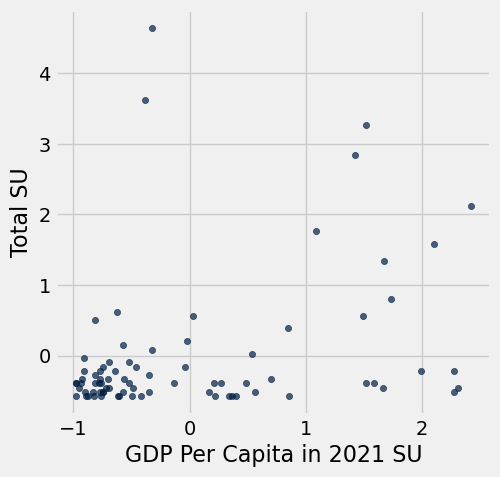

In [232]:
everything_su.scatter("GDP Per Capita in 2021 SU", "Total SU")

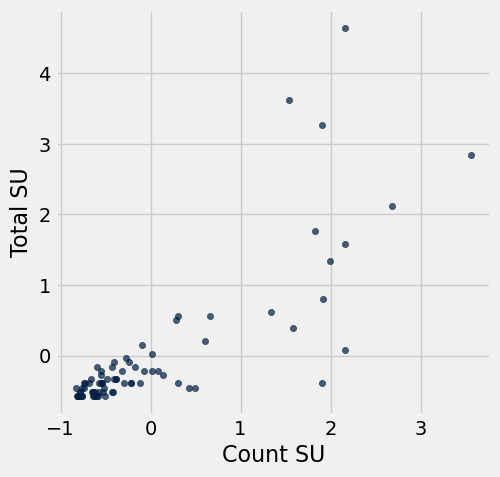

In [233]:
everything_su.scatter("Count SU", "Total SU")

In [234]:
def correlation(arr1, arr2):
    return np.mean(standard_units(arr1) * standard_units(arr2))

count_total = correlation(everything_su.column("Count SU"), everything_su.column("Total SU"))
count_total

0.79864103085219762

In [235]:
gdp_total = correlation(everything_su.column("GDP Per Capita in 2021 SU"), everything_su.column("Total SU"))
gdp_total

0.31722078126057168

In [236]:
def hyp_test(x, y, sims=5000, stat=np.corrcoef):
    
 
    observed_stat = stat(x, y)[0, 1]
    tester = np.empty(sims)
    
    for i in range(sims):
        permuted_data = np.random.permutation(x)
        tester[i] = stat(permuted_data, y)[0, 1]

    p_value = np.sum(tester >= observed_stat) / sims
    return p_value


hyp_test(everything.column("count"), everything.column("Total"))

0.0

In [237]:
def regression_parameters(x, y):
    correlation = np.mean(standard_units(x) * standard_units(y))
    slope = correlation * np.std(y)/np.std(x)
    intercept = np.mean(y) - slope * np.mean(x)
    return make_array(slope, intercept)

parameters = regression_parameters(everything.column("count"), everything.column("Total"))
parameters

array([ 0.10057814, -0.90534613])

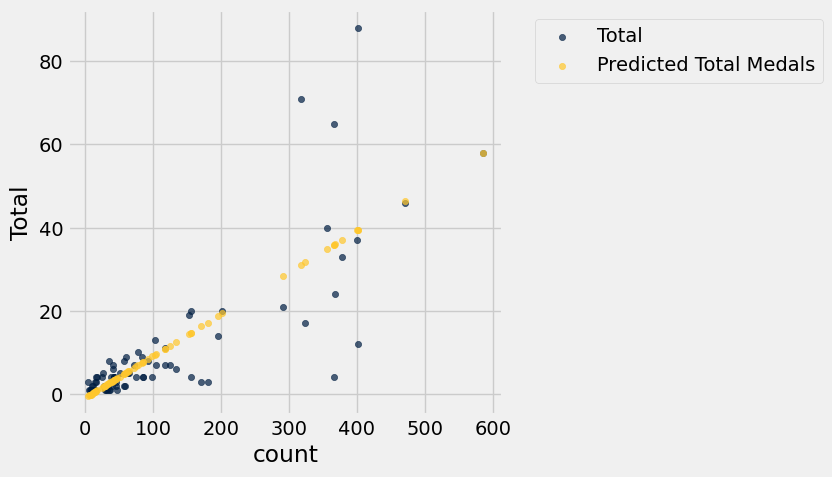

In [238]:
predicted_total_medals = (0.10057814 * everything["count"]) -0.90534613

(everything.with_column("Predicted Total Medals", predicted_total_medals)
 .select("count", "Total", "Predicted Total Medals")
 .scatter("count"))
plt.ylabel("Total");

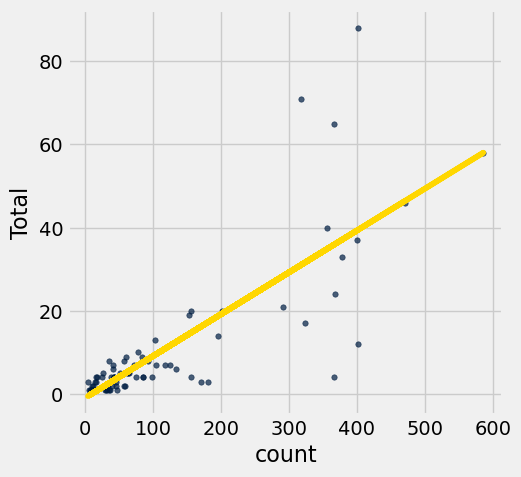

In [239]:
def correlation(t, label_x, label_y):
    return np.mean(standard_units(t.column(label_x))*standard_units(t.column(label_y)))

def slope(t, label_x, label_y):
    r = correlation(t, label_x, label_y)
    return r*np.std(t.column(label_y))/np.std(t.column(label_x))

def intercept(t, label_x, label_y):
    return np.mean(t.column(label_y)) - slope(t, label_x, label_y)*np.mean(t.column(label_x))

def fit(table, x, y):
    a = slope(table, x, y)
    b = intercept(table, x, y)
    return a * table.column(x) + b

def scatter_fit(table, x, y):
    table.scatter(x, y, s=15)
    plt.plot(table.column(x), fit(table, x, y), lw=4, color='gold')
    plt.xlabel(x)
    plt.ylabel(y)

scatter_fit(everything, 'count', 'Total')

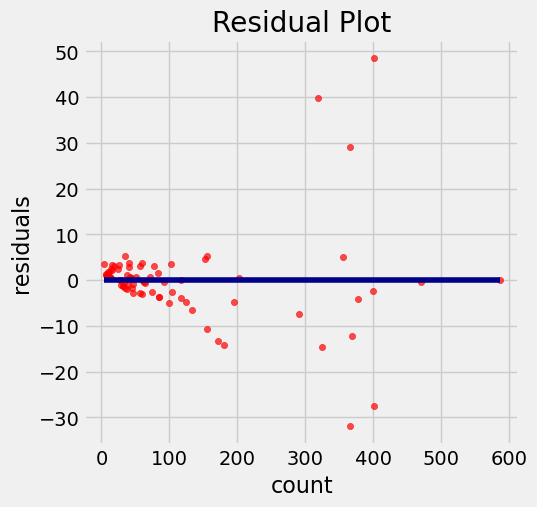

In [240]:
def residual(table, x, y):
    return table.column(y) - fit(table, x, y)

def residual_plot(table, x, y):
    x_array = table.column(x)
    t = Table().with_columns(
            x, x_array,
            'residuals', residual(table, x, y)
        )
    t.scatter(x, 'residuals', color='r')
    xlims = make_array(min(x_array), max(x_array))
    plt.plot(xlims, make_array(0, 0), color='darkblue', lw=4)
    plt.title('Residual Plot')

residual_plot(everything, 'count', 'Total')

In [241]:
slope(everything, 'count', 'Total')

0.10057814064282367

In [242]:
def bootstrap_slope(table, x, y, repetitions):
    
    slopes = make_array()
    for i in np.arange(repetitions):
        bootstrap_sample = table.sample()
        bootstrap_slope = slope(bootstrap_sample, x, y)
        slopes = np.append(slopes, bootstrap_slope)
    
    left = percentile(2.5, slopes)
    right = percentile(97.5, slopes)
    
    observed_slope = slope(table, x, y)
    
    Table().with_column('Bootstrap Slopes', slopes).hist(bins=20)
    plt.plot(make_array(left, right), make_array(0, 0), color='yellow', lw=8);
    print('Slope of regression line:', observed_slope)
    print('Approximate 95%-confidence interval for the true slope:')
    print(left, right)

Slope of regression line: 0.100578140643
Approximate 95%-confidence interval for the true slope:
0.0684309000114 0.133796082373


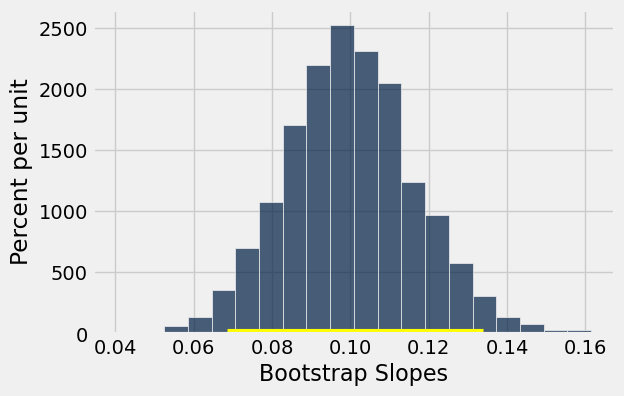

In [244]:
bootstrap_slope(everything, 'count', 'Total', 5000)